# vbOCP — Test 1: pipeline completa

Notebook orchestratore bash-style: le celle di codice lanciano solo comandi verso gli script della repo — nessuna logica del modello qui dentro. Stesso pattern per Colab/cluster: cambia solo dove lo lanci.

**Contenuto:**
1. Setup (path della repo)
2. FOM — solve singolo + plot, generazione snapshot
3. ROM (POD) — training + plot decadimento autovalori
4. GNN *(da aggiungere)*
5. Autoencoder *(da aggiungere)*

## 0. Setup Colab (installazione + clone repo)

Copia di `run_pipeline.ipynb` pensata per girare su un kernel Colab, dove il filesystem locale non e' visibile - la repo va clonata da GitHub a ogni sessione. La mesh usata da `configs/test1.yaml` e' inclusa nel repo (eccezione in `.gitignore`, ~1.5MB) cosi' non serve rigenerarla. Il resto del notebook e' identico all'originale (stesso pattern bash-style).

In [ ]:
GITHUB_URL = 'https://github.com/roccnroll/vbOCP.git'
REPO_DIR = 'vbOCP'

!pip install -q pypolydim gmsh

import os
if not os.path.isdir(REPO_DIR):
    !git clone {GITHUB_URL} {REPO_DIR}
else:
    print(f"{REPO_DIR} gia' presente (skip clone) - se vuoi aggiornarla: !cd {REPO_DIR} && git pull")

os.chdir(REPO_DIR)
print('cwd:', os.getcwd())

## 1. Setup

In [1]:
import os

# si sposta nella root della repo (dove c'e' src/), indipendentemente da dove parte il kernel
while not os.path.isdir('src') and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir('..')
assert os.path.isdir('src'), "src/ non trovata: verifica dove e' montata la repo vbOCP"

REPO_ROOT      = os.getcwd()
CONFIG_PATH    = os.path.join('configs', 'test1.yaml')
DATA_DIR       = os.path.join('data')
SNAPSHOTS_DIR  = os.path.join('data', 'snapshots')
OUTPUT_DIR     = os.path.join('notebooks', 'output')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SNAPSHOTS_DIR, exist_ok=True)

print('REPO_ROOT    :', REPO_ROOT)
print('CONFIG_PATH  :', CONFIG_PATH)
print('SNAPSHOTS_DIR:', SNAPSHOTS_DIR)

REPO_ROOT    : /shared/vbOCP
CONFIG_PATH  : configs/test1.yaml
SNAPSHOTS_DIR: data/snapshots


## 2. FOM

### 2.1 Solve singolo + plot

Risolve il FOM per una terna di parametri e salva un confronto visivo di stato `y` e aggiunto `p`. Modifica `--mu1`/`--mu2`/`--mu_u` per esplorare altri punti dello spazio parametrico.

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Nh = 5306
Assembly operatori (indipendenti da mu) ...
Assembly matrice di controllo C(mu_u=0.5) ...
Solve OTD per mu1=12.0, mu2=2.5, mu_u=0.5 ...
Soluzione OTD:
  stato     y: min=1.0000, max=3.4809
  aggiunto  p: min=0.0001, max=0.3643
  controllo u: min=0.0019, max=5.2048
Plot salvato in /tmp/fom_solution.png
PLOT_PATH=/tmp/fom_solution.png


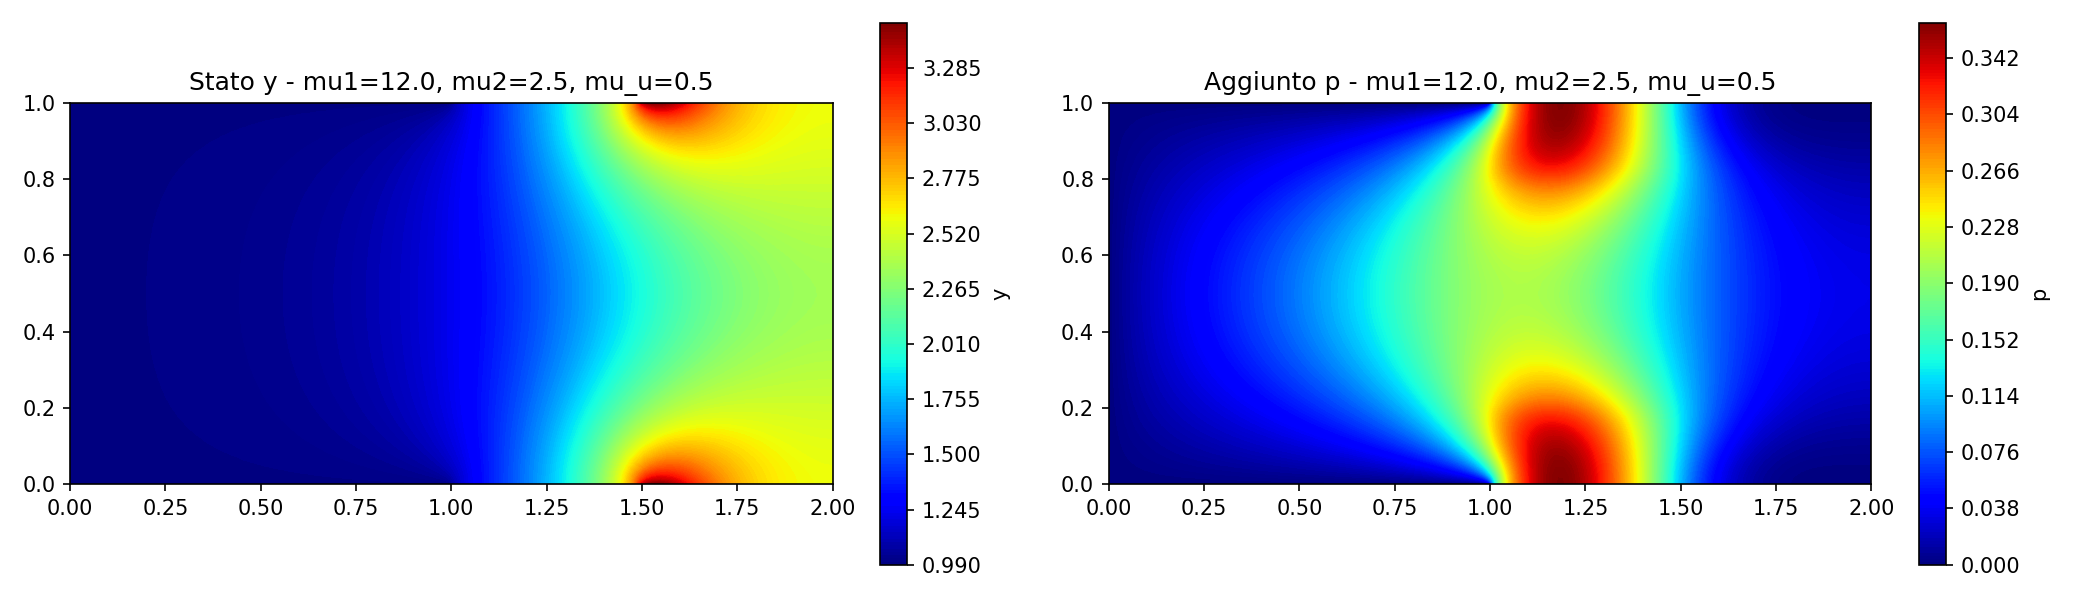

In [2]:
!python -m src.full_order.run_single_solve \
    --config {CONFIG_PATH} \
    --mu1 12 \
    --mu2 2.5 \
    --mu_u 0.5 \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'fom_solution.png'))

### 2.2 Generazione snapshot (training + test)

Campiona `mu1`, `mu2`, `mu_u` uniformemente sui range definiti nel config e risolve il FOM per ciascun campione. L'assembly indipendente da mu viene fatto una sola volta; il ciclo aggiorna solo la matrice di controllo e il solve.

Due set separati (seed diversi): uno di **training** (per la POD) e uno di **test** (mai visto durante la POD, per validare il ROM). Se un file esiste gia', **non viene rigenerato** (skip).

Output: un `.npz` per set, con `mu1`, `mu2`, `mu_u`, e le matrici `Y`, `P`, `U` (una colonna per campione).

In [3]:
N_SAMPLES = 300
N_TEST = 150
TEST_SEED = 123  # diverso dal seed di default usato per il training (42)

SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_{N_SAMPLES}.npz')
TEST_SNAPSHOTS_PATH = os.path.join(SNAPSHOTS_DIR, f'test1_test{N_TEST}.npz')

if os.path.exists(SNAPSHOTS_PATH):
    print(f"Training set gia' presente: {SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_SAMPLES} \
        --output {SNAPSHOTS_PATH}

if os.path.exists(TEST_SNAPSHOTS_PATH):
    print(f"Test set gia' presente: {TEST_SNAPSHOTS_PATH} (skip)")
else:
    !python -m src.full_order.generate_snapshots \
        --config {CONFIG_PATH} \
        --n-samples {N_TEST} \
        --seed {TEST_SEED} \
        --output {TEST_SNAPSHOTS_PATH}

Training set gia' presente: data/snapshots/test1_300.npz (skip)
Test set gia' presente: data/snapshots/test1_test150.npz (skip)


In [4]:
import numpy as np

data = np.load(SNAPSHOTS_PATH)
print('Training - chiavi:', list(data.keys()), ' Y shape:', data['Y'].shape)

test_data = np.load(TEST_SNAPSHOTS_PATH)
print('Test     - chiavi:', list(test_data.keys()), ' Y shape:', test_data['Y'].shape)

Training - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 300)
Test     - chiavi: ['mu1', 'mu2', 'mu_u', 'Y', 'P', 'U']  Y shape: (5306, 150)


## 3. ROM (POD)

### 3.1 Stato e aggiunto

Costruisce la base POD per stato e aggiunto a partire dagli snapshot generati sopra. Il numero di modi N e' scelto automaticamente in base a una soglia di energia cumulata (non piu' fisso). Prodotto scalare configurabile qui sotto; `--plot` mostra subito il decadimento degli autovalori (nessun path da gestire).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Prodotto scalare: seminorm
Caricamento snapshot da data/snapshots/test1_300.npz ...
Y shape: (5306, 300), P shape: (5306, 300)
N scelto: stato=71, aggiunto=18 (indipendenti)
Base POD salvata in data/snapshots/test1_pod.npz
Plot salvato in /tmp/pod_eigenvalue_decay.png
PLOT_PATH=/tmp/pod_eigenvalue_decay.png


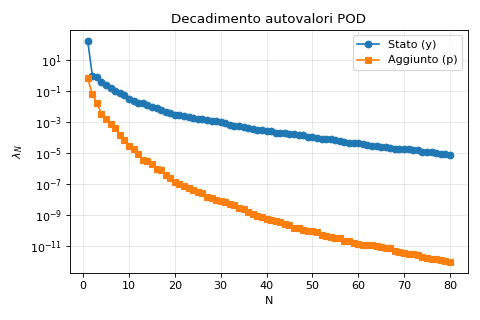

In [5]:
INNER_PRODUCT = 'seminorm'  # 'seminorm' (solo A_diff) o 'full' (A_diff + M_full)
ENERGY_THRESHOLD = 1-1e-6   # N scelto automaticamente in base a questa soglia
POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_pod.npz')

!python -m src.rom.train_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --inner-product {INNER_PRODUCT} \
    --energy-threshold {ENERGY_THRESHOLD} \
    --output {POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'pod_eigenvalue_decay.png'))

Training delle due PODNN (stato e aggiunto, indipendenti - N diverso per ciascuna) e valutazione errore (L2, H1) + speedup rispetto al FOM:

In [6]:
Y_NN_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_y_nn.pt')
P_NN_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_p_nn.pt')
STATE_EPOCHS = 100000
STATE_LR = 1e-3
STATE_HIDDEN_DIM = 32
STATE_N_HIDDEN_LAYERS = 4
N_MODES_Y = 14  # es. 13 - lascia None per usare quelli scelti automaticamente dalla POD (soglia energia)
N_MODES_P = 9  # es. 9  - lascia None per usare quelli scelti automaticamente dalla POD (soglia energia)

y_n_modes_flag = f'--n-modes {N_MODES_Y}' if N_MODES_Y is not None else ''
p_n_modes_flag = f'--n-modes {N_MODES_P}' if N_MODES_P is not None else ''

!python -m src.rom.train_reduced_nn \
    --pod-model {POD_PATH} \
    --field y \
    --epochs {STATE_EPOCHS} \
    --lr {STATE_LR} \
    --hidden-dim {STATE_HIDDEN_DIM} \
    --n-hidden-layers {STATE_N_HIDDEN_LAYERS} \
    {y_n_modes_flag} \
    --output {Y_NN_PATH}

!python -m src.rom.train_reduced_nn \
    --pod-model {POD_PATH} \
    --field p \
    --epochs {STATE_EPOCHS} \
    --lr {STATE_LR} \
    --hidden-dim {STATE_HIDDEN_DIM} \
    --n-hidden-layers {STATE_N_HIDDEN_LAYERS} \
    {p_n_modes_flag} \
    --output {P_NN_PATH}

Caricamento base POD da data/snapshots/test1_pod.npz (campo: y) ...
N modi: 14 (esplicito, su 71 disponibili)
Training FFNN mu -> coefficienti POD(y) (normalizzati) ...
  epoch 2000  loss 6.895795e-03  lr 1.0e-03  device cpu
  epoch 4000  loss 2.855421e-03  lr 1.0e-03  device cpu
  epoch 6000  loss 1.783784e-03  lr 1.0e-03  device cpu
  epoch 8000  loss 1.343773e-03  lr 1.0e-03  device cpu
  epoch 10000  loss 1.116565e-03  lr 1.0e-03  device cpu
  epoch 12000  loss 9.409700e-04  lr 1.0e-03  device cpu
  epoch 14000  loss 8.287366e-04  lr 1.0e-03  device cpu
  epoch 16000  loss 8.475622e-04  lr 1.0e-03  device cpu
  epoch 18000  loss 6.747038e-04  lr 1.0e-03  device cpu
  epoch 20000  loss 7.086305e-04  lr 1.0e-03  device cpu
  epoch 22000  loss 6.276103e-04  lr 1.0e-03  device cpu
  epoch 24000  loss 5.694525e-04  lr 1.0e-03  device cpu
  epoch 26000  loss 5.119098e-04  lr 1.0e-03  device cpu
^C
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_mai

### 3.2 Controllo (PODNN)

`u` non e' un campo di dominio come `y` - e' una traccia 1D sul bordo dove il controllo puo' essere attivo, mascherata a zero fuori Gamma_C (per definizione: `u = dy/dn = 0` su Gamma_N). La POD si fa su questa traccia (prodotto scalare euclideo), poi una piccola FFNN impara `mu -> coefficienti proiettati` (pattern PODNN, `Lab9/PODnn.ipynb` del prof).

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
Estrazione traccia di controllo sul bordo ...
Traccia: 276 nodi di bordo, 300 snapshot
N modi scelto: 15
Plot salvato in /tmp/control_pod_eigenvalue_decay.png
PLOT_PATH=/tmp/control_pod_eigenvalue_decay.png
Base POD + coefficienti + mu di training salvati in data/snapshots/test1_control_pod.npz


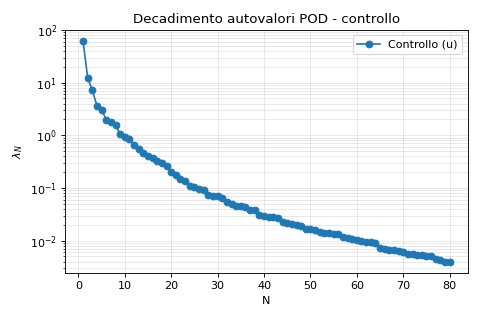

In [7]:
CONTROL_POD_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_control_pod.npz')
CONTROL_ENERGY_THRESHOLD = 1 - 1e-6   # N scelto automaticamente in base a questa soglia
CONTROL_MAX_MODES = 15                 # tetto massimo, anche se la soglia non e' raggiunta

!python -m src.rom.build_control_pod \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --energy-threshold {CONTROL_ENERGY_THRESHOLD} \
    --max-modes {CONTROL_MAX_MODES} \
    --output {CONTROL_POD_PATH} \
    --plot

import tempfile, os as _os
from IPython.display import Image
Image(_os.path.join(tempfile.gettempdir(), 'control_pod_eigenvalue_decay.png'))

Errore di ricostruzione della **sola base POD** (proiezione di Galerkin, senza rete) sul test set — isola quanto e' brava la base da quanto impara bene la rete:

In [8]:
!python -m src.rom.evaluate_control_pod \
    --config {CONFIG_PATH} \
    --pod-model {CONTROL_POD_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento base POD da data/snapshots/test1_control_pod.npz ...
Caricamento test set da data/snapshots/test1_test150.npz ...
Estrazione traccia di controllo vera (test set) ...
Proiezione di Galerkin sulla base (miglior ricostruzione possibile con N modi) ...
N modi: 15
Errore relativo medio (solo POD, senza rete): 4.4813e-01
Errore relativo mediano: 4.5350e-01
Errore relativo max: 7.1994e-01


Sweep dell'errore solo-POD del controllo al variare di N (nessuna rete, veloce - solo algebra lineare):

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento snapshot da data/snapshots/test1_300.npz ...
Base costruita su marker (8, 10)  nodi di bordo: 276
Caricamento test set da data/snapshots/test1_test150.npz ...
Valutata su marker (8, 10)  nodi di bordo: 276
N=10  err_u_pod=5.5768e-01
N=20  err_u_pod=3.8687e-01
N=30  err_u_pod=2.9554e-01
N=40  err_u_pod=2.4384e-01
N=50  err_u_pod=1.9982e-01
N=60  err_u_pod=1.6909e-01
N=70  err_u_pod=1.3961e-01
N=80  err_u_pod=1.1313e-01
N=90  err_u_pod=9.4040e-02
N=100  err_u_pod=7.1029e-02

Risultati salvati in data/snapshots/sweep_control_pod_error.csv
Plot salvato in data/snapshots/sweep_control_pod_error.png


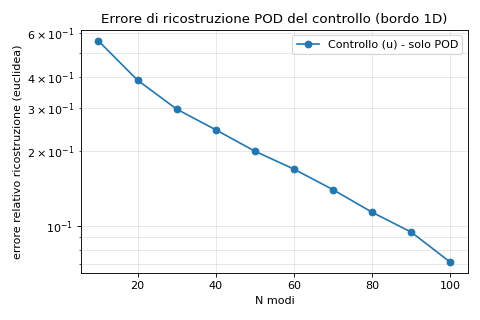

In [9]:
CONTROL_SWEEP_VALUES = '10,20,30,40,50,60,70,80,90,100'
CONTROL_SWEEP_OUTPUT = os.path.join(SNAPSHOTS_DIR, 'sweep_control_pod_error.csv')

!python -m src.rom.sweep_control_pod_error \
    --config {CONFIG_PATH} \
    --snapshots {SNAPSHOTS_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH} \
    --values {CONTROL_SWEEP_VALUES} \
    --output {CONTROL_SWEEP_OUTPUT}

from pathlib import Path
from IPython.display import Image
Image(str(Path(CONTROL_SWEEP_OUTPUT).with_suffix('.png')))

Training della rete (parametri modificabili qui, indipendenti dalla POD sopra):

In [10]:
CONTROL_NN_PATH = os.path.join(SNAPSHOTS_DIR, 'test1_u_nn.pt')
EPOCHS = 100000
LR = 1e-3
HIDDEN_DIM = 30         # neuroni per layer nascosto
N_HIDDEN_LAYERS = 4     # numero di layer nascosti
N_MODES_U = None  # es. 8 - lascia None per usare quelli scelti automaticamente dalla POD (soglia energia)

u_n_modes_flag = f'--n-modes {N_MODES_U}' if N_MODES_U is not None else ''

!python -m src.rom.train_reduced_nn \
    --pod-model {CONTROL_POD_PATH} \
    --field u \
    --epochs {EPOCHS} \
    --lr {LR} \
    --hidden-dim {HIDDEN_DIM} \
    --n-hidden-layers {N_HIDDEN_LAYERS} \
    {u_n_modes_flag} \
    --output {CONTROL_NN_PATH}

Caricamento base POD da data/snapshots/test1_control_pod.npz (campo: u) ...
N modi: 15 (automatico, dalla soglia di energia della POD)
Training FFNN mu -> coefficienti POD(u) (normalizzati) ...
  epoch 2000  loss 1.928712e-02  lr 1.0e-03  device cpu
  epoch 4000  loss 6.285083e-03  lr 1.0e-03  device cpu
  epoch 6000  loss 3.479738e-03  lr 1.0e-03  device cpu
  epoch 8000  loss 2.620056e-03  lr 1.0e-03  device cpu
  epoch 10000  loss 1.869077e-03  lr 1.0e-03  device cpu
  epoch 12000  loss 1.517160e-03  lr 1.0e-03  device cpu
  epoch 14000  loss 1.326522e-03  lr 1.0e-03  device cpu
  epoch 16000  loss 1.108021e-03  lr 1.0e-03  device cpu
  epoch 18000  loss 9.970800e-04  lr 1.0e-03  device cpu
  epoch 20000  loss 1.229707e-03  lr 1.0e-03  device cpu
  epoch 22000  loss 9.573334e-04  lr 1.0e-03  device cpu
  epoch 24000  loss 8.266010e-04  lr 1.0e-03  device cpu
  epoch 26000  loss 7.710708e-04  lr 1.0e-03  device cpu
  epoch 28000  loss 7.886994e-04  lr 1.0e-03  device cpu
  epoch 3000

In [11]:
!python -m src.rom.evaluate_control_podnn \
    --config {CONFIG_PATH} \
    --pod-model {CONTROL_POD_PATH} \
    --weights {CONTROL_NN_PATH} \
    --test-snapshots {TEST_SNAPSHOTS_PATH}

Caricamento mesh da data/meshes/test1_uniform_corner_refined_ctrl ...
Caricamento base POD da data/snapshots/test1_control_pod.npz ...
Caricamento statistiche di normalizzazione e architettura da data/snapshots/test1_u_nn.norm.npz ...
Caricamento pesi rete da data/snapshots/test1_u_nn.pt (hidden_dim=30, n_hidden_layers=4) ...
Caricamento test set da data/snapshots/test1_test150.npz ...
Estrazione traccia di controllo vera (test set) ...
Predizione con la PODNN ...
Errore relativo medio: 6.1536e-01
Errore relativo mediano: 5.3216e-01
Errore relativo max: 3.8601e+00


## 4. GNN

*(da aggiungere)*

## 5. Autoencoder

*(da aggiungere)*